In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import numpy as np
from utils import extract_features

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.utils import shuffle

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.21.0


In [2]:
X = []
y = []

labels = {"real": 0, "fake": 1}

for folder in ["real", "fake"]:
    path = os.path.join("dataset", folder)

    for file in os.listdir(path):
        file_path = os.path.join(path, file)

        features = extract_features(file_path)

        if features is not None:
            X.append(features)
            y.append(labels[folder])

X = np.array(X)
y = np.array(y)

X = X[..., np.newaxis]

print("Dataset shape:", X.shape)

Dataset shape: (1600, 128, 128, 1)


In [3]:
X, y = shuffle(X, y, random_state=42)

In [4]:
print("Class distribution:", np.bincount(y))

Class distribution: [800 800]


In [5]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,1)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

C:\Users\NIHARIKA\OneDrive\Documents\Projects\deepfake_audio_detection\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [7]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

In [8]:
history = model.fit(
    X, y,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 117ms/step - accuracy: 0.8219 - loss: 0.4301 - val_accuracy: 0.8188 - val_loss: 0.3981
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 113ms/step - accuracy: 0.8648 - loss: 0.3486 - val_accuracy: 0.8219 - val_loss: 0.3793
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 112ms/step - accuracy: 0.8703 - loss: 0.3279 - val_accuracy: 0.8625 - val_loss: 0.3446
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 109ms/step - accuracy: 0.8805 - loss: 0.2993 - val_accuracy: 0.8719 - val_loss: 0.3483
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 109ms/step - accuracy: 0.8969 - loss: 0.2582 - val_accuracy: 0.8813 - val_loss: 0.3265
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 108ms/step - accuracy: 0.9070 - loss: 0.2280 - val_accuracy: 0.8781 - val_loss: 0.3054
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 107ms/step - accuracy: 0.9273 - loss: 0.1907 - val_accuracy: 0.8969 - val_loss: 0.2970
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 107ms/step - accuracy: 0.9398 - loss: 0.1574 - val_accuracy: 0.

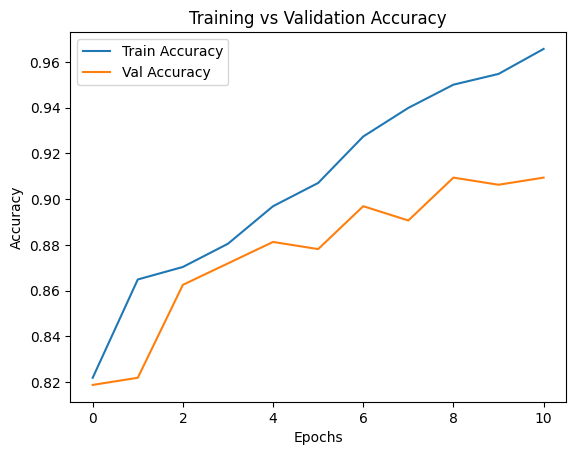

In [11]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title("Training vs Validation Accuracy")

plt.show()

In [12]:
pred = model.predict(X[:10]).flatten()

print("Predictions:", pred)
print("Actual:", y[:10])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
Predictions: [0.04094214 0.00388427 0.00165284 0.01515527 0.93164855 0.99237657
 0.868098   0.01041141 0.01264036 0.20131996]
Actual: [0 0 0 0 1 1 1 0 0 0]


In [13]:
model.save("deepfake_detector.h5")
print("Model saved successfully!")

Model saved successfully!
